# Wind Farm Yaw Control via PPO (Proximal Policy Optimization)

This notebook trains a PPO agent to maximize total power output by controlling the yaw angles of 3 turbines in the `Turb3_Row1_Floris` environment.

**Baselines to beat** (from the GP notebook, fixed wind: 8 m/s, 270°):
- Random policy:  ~228 total reward / episode  
- GP + gradient optimizer: ~232 total reward / episode

**Algorithm**: PPO with clipped surrogate objective, GAE(λ), and shared Actor-Critic backbone.

In [1]:
!pip install -q git+https://github.com/ifpen/wfcrl-env.git tabpfn-client torch-geometric python-dotenv "numpy==2.0.2" "scipy==1.16.3" "scikit-learn==1.6.1"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 12.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

from wfcrl import environments as envs

sns.set_theme(style="whitegrid")
SEED = 13

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Environment Setup

In [4]:
env = envs.make(
    "Turb3_Row1_Floris",
    max_num_steps=150,
    controls={"yaw": (-45, 45, 5)},  # range in degrees, step degrees per action
    continuous_control=True,
    log=True,
)

N_TURBINES = env.num_turbines
print(f"Turbines: {N_TURBINES}")
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Controls:          {env.controls}")

Turbines: 3
Observation space: Dict('yaw': Box(-45.0, 45.0, (3,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (3,), float32), 'wind_direction': Box(0.0, 360.0, (3,), float32))
Action space:      Dict('yaw': Box(-5.0, 5.0, (3,), float32))
Controls:          {'yaw': (-45, 45, 5)}


In [5]:
# Precompute normalization bounds directly from the obs space
_OBS_KEYS = ["yaw", "freewind_measurements", "wind_speed", "wind_direction"]
_OBS_LOW  = np.concatenate([env.observation_space[k].low  for k in _OBS_KEYS]).astype(np.float32)
_OBS_HIGH = np.concatenate([env.observation_space[k].high for k in _OBS_KEYS]).astype(np.float32)


def flatten_obs(obs: dict) -> np.ndarray:
    """Convert Dict obs to a normalized flat vector in [-1, 1].

    Raw features span very different scales (yaw: ±20, wind direction: 0–360).
    Normalizing to [-1, 1] prevents wind-direction values from dominating the
    first linear layer and keeps all gradients on the same scale.
    """
    raw = np.concatenate([obs[k] for k in _OBS_KEYS]).astype(np.float32)
    return 2.0 * (raw - _OBS_LOW) / (_OBS_HIGH - _OBS_LOW) - 1.0


def env_reset(seed_val, options):
    """Call env.reset() and always return just the obs dict."""
    result = env.reset(seed=seed_val, options=options)
    return result[0] if isinstance(result, tuple) else result


OBS_DIM = 3 + 2 + 3 + 3  # = 11
ACT_DIM = N_TURBINES       # = 3  (continuous yaw delta per turbine)
print(f"obs_dim={OBS_DIM}, act_dim={ACT_DIM}")
print(f"obs_low:  {_OBS_LOW}")
print(f"obs_high: {_OBS_HIGH}")

obs_dim=11, act_dim=3
obs_low:  [-45. -45. -45.   3.   0.   3.   3.   3.   0.   0.   0.]
obs_high: [ 45.  45.  45.  28. 360.  28.  28.  28. 360. 360. 360.]


## Actor-Critic Network

In [6]:
LOG_STD_MIN = -3  # std >= exp(-3) ≈ 0.05; prevents near-zero std → huge PPO ratios

class ActorCritic(nn.Module):
    """
    Shared-backbone Actor-Critic for continuous actions.
    Actor: outputs a Gaussian (mean, log_std) over actions.
    Critic: outputs a scalar state value.
    """
    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(hidden_dim, act_dim)
        self.actor_log_std = nn.Parameter(torch.zeros(act_dim))  # learnable log-std
        self.critic        = nn.Linear(hidden_dim, 1)

        # Orthogonal init (standard for PPO)
        for layer in self.backbone:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.actor_mean.weight, gain=0.01)
        nn.init.zeros_(self.actor_mean.bias)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

    def _std(self) -> torch.Tensor:
        """Clamped std to prevent collapse to near-zero, which causes huge PPO ratios."""
        return self.actor_log_std.clamp(min=LOG_STD_MIN).exp()

    def _dist(self, obs: torch.Tensor) -> Normal:
        features = self.backbone(obs)
        return Normal(self.actor_mean(features), self._std().expand_as(self.actor_mean(features)))

    def act(self, obs: torch.Tensor):
        """Sample action; return (action, log_prob, value)."""
        features = self.backbone(obs)
        mean     = self.actor_mean(features)
        std      = self._std().expand_as(mean)
        dist     = Normal(mean, std)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        value    = self.critic(features).squeeze(-1)
        return action, log_prob, value

    def evaluate(self, obs: torch.Tensor, action: torch.Tensor):
        """Re-evaluate stored (obs, action) pairs for the PPO loss."""
        features = self.backbone(obs)
        mean     = self.actor_mean(features)
        std      = self._std().expand_as(mean)
        dist     = Normal(mean, std)
        log_prob = dist.log_prob(action).sum(-1)
        entropy  = dist.entropy().sum(-1)
        value    = self.critic(features).squeeze(-1)
        return log_prob, entropy, value


policy = ActorCritic(OBS_DIM, ACT_DIM).to(DEVICE)
print(policy)

ActorCritic(
  (backbone): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (actor_mean): Linear(in_features=128, out_features=3, bias=True)
  (critic): Linear(in_features=128, out_features=1, bias=True)
)


## PPO Hyperparameters

In [7]:
# ── Training budget ───────────────────────────────────────────────────────────
N_EPISODES = 5000
EVAL_EVERY = 50    # print progress every N episodes

# ── PPO update ────────────────────────────────────────────────────────────────
LR         = 3e-4
N_EPOCHS   = 10    # update passes per collected episode
BATCH_SIZE = 32
GAMMA      = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS   = 0.2
VF_COEF    = 0.5
ENT_COEF   = 0.01  # raised from 1e-3 to encourage exploration early in training
MAX_GRAD   = 0.5

optimizer = optim.Adam(policy.parameters(), lr=LR, eps=1e-5)

## PPO Training Loop

In [8]:
def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    """
    Generalized Advantage Estimation (GAE-λ).
    Episode always terminates, so bootstrap value = 0.
    """
    T          = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae        = 0.0
    next_value = 0.0
    for t in reversed(range(T)):
        mask           = 1.0 - dones[t]
        delta          = rewards[t] + gamma * next_value * mask - values[t]
        gae            = delta + gamma * lam * mask * gae
        advantages[t]  = gae
        next_value     = values[t]
    returns = advantages + np.array(values, dtype=np.float32)
    return advantages, returns

In [9]:
def ppo_update(obs_buf, act_buf, logp_buf, adv_buf, ret_buf):
    """Mini-batch PPO update over N_EPOCHS passes."""
    obs_t  = torch.tensor(obs_buf,  dtype=torch.float32, device=DEVICE)
    act_t  = torch.tensor(act_buf,  dtype=torch.float32, device=DEVICE)
    logp_t = torch.tensor(logp_buf, dtype=torch.float32, device=DEVICE)
    adv_t  = torch.tensor(adv_buf,  dtype=torch.float32, device=DEVICE)
    ret_t  = torch.tensor(ret_buf,  dtype=torch.float32, device=DEVICE)

    # Skip update if buffer contains NaN (e.g. from env returning bad values)
    if not (obs_t.isfinite().all() and act_t.isfinite().all()):
        return {"pg": 0.0, "vf": 0.0, "ent": 0.0}

    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)  # normalize advantages
    # Normalize returns so the critic target is O(1) rather than O(200).
    # Without this, VF loss dominates training and the critic never converges.
    ret_t = (ret_t - ret_t.mean()) / (ret_t.std() + 1e-8)

    N = len(obs_t)
    total_pg = total_vf = total_ent = 0.0
    n_batches = 0

    for _ in range(N_EPOCHS):
        for b in torch.randperm(N, device=DEVICE).split(BATCH_SIZE):
            new_logp, entropy, new_val = policy.evaluate(obs_t[b], act_t[b])

            ratio    = (new_logp - logp_t[b]).exp()
            pg_loss  = -torch.min(
                ratio * adv_t[b],
                torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t[b]
            ).mean()
            vf_loss  = ((new_val - ret_t[b]) ** 2).mean()
            ent_loss = -entropy.mean()

            (pg_loss + VF_COEF * vf_loss + ENT_COEF * ent_loss).backward()
            # Skip optimizer step if gradients contain NaN/inf to prevent
            # NaN from propagating into the network weights.
            grad_norm = nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD)
            if torch.isfinite(grad_norm):
                optimizer.step()
            optimizer.zero_grad()

            total_pg  += pg_loss.item()
            total_vf  += vf_loss.item()
            total_ent += ent_loss.item()
            n_batches += 1

    return {"pg": total_pg / n_batches,
            "vf": total_vf / n_batches,
            "ent": total_ent / n_batches}

In [10]:
WIND_OPTS = {"wind_speed": 8, "wind_direction": 270}  # fixed scenario (Sc.1)

episode_rewards = []
loss_log = {"pg": [], "vf": [], "ent": []}

for ep in range(N_EPISODES):
    obs_dict = env_reset(SEED + ep, WIND_OPTS)

    obs_buf = []
    act_buf = []
    logp_buf = []
    rew_buf = []
    val_buf = []
    done_buf = []
    ep_reward = 0.0
    done = False

    while not done:
        obs_np = flatten_obs(obs_dict)
        obs_t  = torch.tensor(obs_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            action_t, logp_t, val_t = policy.act(obs_t)

        action_np    = action_t.squeeze(0).cpu().numpy()  # (3,)
        joint_action = {"yaw": action_np}

        obs_dict, reward, termination, truncation, info = env.step(joint_action)
        r = float(reward[0]) if hasattr(reward, "__len__") else float(reward)

        obs_buf.append(obs_np)
        act_buf.append(action_np)
        logp_buf.append(logp_t.item())
        rew_buf.append(r)
        val_buf.append(val_t.item())
        done_buf.append(float(termination or truncation))
        ep_reward += r
        done = termination or truncation

    episode_rewards.append(ep_reward)

    adv_buf, ret_buf = compute_gae(rew_buf, val_buf, done_buf)
    losses = ppo_update(
        np.array(obs_buf), np.array(act_buf),
        np.array(logp_buf), adv_buf, ret_buf
    )
    for k, v in losses.items():
        loss_log[k].append(v)

    if (ep + 1) % EVAL_EVERY == 0:
        recent = np.mean(episode_rewards[-EVAL_EVERY:])
        print(f"Ep {ep+1:4d} | mean reward ({EVAL_EVERY}-ep avg): {recent:.2f} "
              f"| pg={losses['pg']:.4f}  vf={losses['vf']:.4f}  ent={losses['ent']:.4f}")

print("\nTraining complete.")

Ep   50 | mean reward (50-ep avg): 227.96 | pg=-0.0140  vf=1.1721  ent=-4.5009
Ep  100 | mean reward (50-ep avg): 233.03 | pg=-0.0003  vf=0.8282  ent=-4.6408
Ep  150 | mean reward (50-ep avg): 235.44 | pg=-0.0053  vf=0.6795  ent=-4.8561
Ep  200 | mean reward (50-ep avg): 236.33 | pg=-0.0210  vf=0.6967  ent=-5.0586
Ep  250 | mean reward (50-ep avg): 249.10 | pg=-0.0140  vf=0.7739  ent=-5.2266
Ep  300 | mean reward (50-ep avg): 257.70 | pg=-0.0085  vf=0.7534  ent=-5.4115
Ep  350 | mean reward (50-ep avg): 264.10 | pg=-0.0081  vf=0.9478  ent=-5.5537
Ep  400 | mean reward (50-ep avg): 249.01 | pg=-0.0067  vf=0.7371  ent=-5.6723
Ep  450 | mean reward (50-ep avg): 242.76 | pg=-0.0083  vf=0.8861  ent=-5.8086
Ep  500 | mean reward (50-ep avg): 232.55 | pg=-0.0038  vf=1.5422  ent=-6.1087
Ep  550 | mean reward (50-ep avg): 228.49 | pg=0.0109  vf=0.4725  ent=-6.3451
Ep  600 | mean reward (50-ep avg): 235.14 | pg=-0.0173  vf=0.5353  ent=-6.4728
Ep  650 | mean reward (50-ep avg): 245.21 | pg=0.5889

/usr/local/lib/python3.12/dist-packages/floris/simulation/wake_deflection/gauss.py:156: RuntimeWarning: divide by zero encountered in divide
  freestream_velocity
/usr/local/lib/python3.12/dist-packages/floris/simulation/wake_deflection/gauss.py:196: RuntimeWarning: divide by zero encountered in divide
  delta_near_wake = ((x - xR) / (x0 - xR)) * delta0 + (self.ad + self.bd * (x - x_i))
/usr/local/lib/python3.12/dist-packages/floris/simulation/wake_deflection/gauss.py:196: RuntimeWarning: invalid value encountered in divide
  delta_near_wake = ((x - xR) / (x0 - xR)) * delta0 + (self.ad + self.bd * (x - x_i))
/usr/local/lib/python3.12/dist-packages/floris/simulation/wake_deflection/gauss.py:196: RuntimeWarning: invalid value encountered in multiply
  delta_near_wake = ((x - xR) / (x0 - xR)) * delta0 + (self.ad + self.bd * (x - x_i))
/usr/local/lib/python3.12/dist-packages/floris/simulation/wake_deflection/gauss.py:202: RuntimeWarning: invalid value encountered in multiply
  sigma_y = si

Ep  750 | mean reward (50-ep avg): 235.99 | pg=0.0777  vf=0.5942  ent=-7.6320
Ep  800 | mean reward (50-ep avg): 222.10 | pg=0.0470  vf=0.6738  ent=-7.5466
Ep  850 | mean reward (50-ep avg): 215.51 | pg=-0.0082  vf=0.5746  ent=-7.3196
Ep  900 | mean reward (50-ep avg): 217.11 | pg=0.0005  vf=0.4250  ent=-6.8560
Ep  950 | mean reward (50-ep avg): 220.24 | pg=-0.0689  vf=0.3769  ent=-6.3657
Ep 1000 | mean reward (50-ep avg): 240.79 | pg=-0.0216  vf=0.8610  ent=-6.3132
Ep 1050 | mean reward (50-ep avg): 241.63 | pg=0.1248  vf=0.7669  ent=-6.4601
Ep 1100 | mean reward (50-ep avg): 234.65 | pg=-0.0243  vf=0.6185  ent=-6.3063
Ep 1150 | mean reward (50-ep avg): 252.70 | pg=-0.0114  vf=0.5938  ent=-6.5446
Ep 1200 | mean reward (50-ep avg): 235.49 | pg=0.0621  vf=0.5997  ent=-6.7116
Ep 1250 | mean reward (50-ep avg): 211.94 | pg=0.1211  vf=0.7647  ent=-6.9810
Ep 1300 | mean reward (50-ep avg): 238.71 | pg=0.1068  vf=1.0103  ent=-7.3376
Ep 1350 | mean reward (50-ep avg): 245.37 | pg=0.0871  vf=0

## Learning Curves

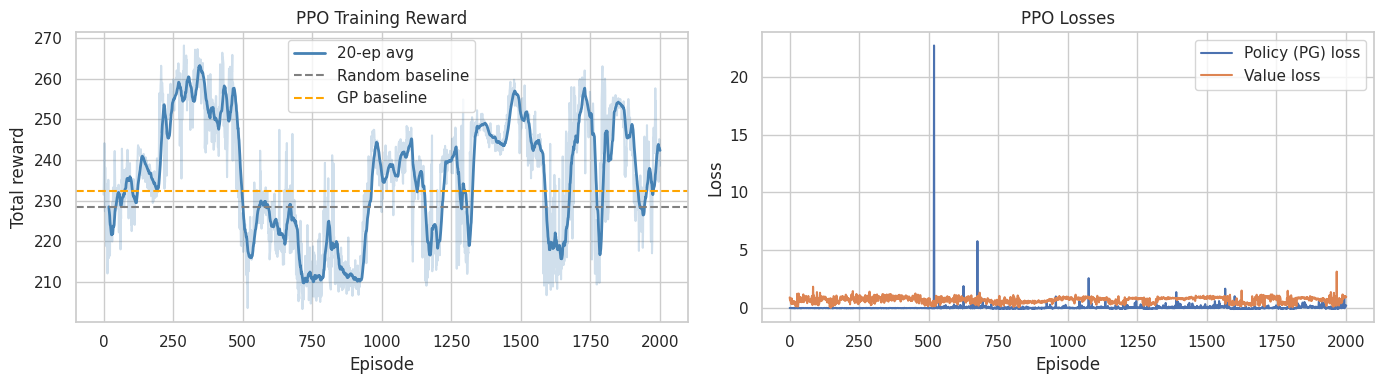

In [ ]:
WINDOW   = 20
smoothed = np.convolve(episode_rewards, np.ones(WINDOW) / WINDOW, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(episode_rewards, alpha=0.25, color="steelblue")
ax.plot(np.arange(WINDOW - 1, len(episode_rewards)), smoothed,
        color="steelblue", linewidth=2, label=f"{WINDOW}-ep avg")
ax.axhline(228.44, color="gray",   linestyle="--", label="Random baseline")
ax.axhline(232.49, color="orange", linestyle="--", label="GP baseline")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("PPO Training Reward")
ax.legend()

ax = axes[1]
ax.plot(loss_log["pg"],  label="Policy (PG) loss")
ax.plot(loss_log["vf"],  label="Value loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO Losses")
ax.legend()

plt.tight_layout()
plt.show()

## Evaluation: Greedy Policy Rollout

Run the trained policy deterministically (actor mean only, no sampling noise).

In [ ]:
def evaluate_policy(n_episodes: int = 5, greedy: bool = True, seed_offset: int = 9000):
    """Return episode reward list and a DataFrame of the first episode's trajectory."""
    policy.eval()
    rewards   = []
    eval_rows = []

    with torch.no_grad():
        for ep in range(n_episodes):
            obs_dict = env_reset(seed_offset + ep, WIND_OPTS)
            done, total_r, step = False, 0.0, 0

            while not done:
                obs_np   = flatten_obs(obs_dict)
                obs_t    = torch.tensor(obs_np, dtype=torch.float32,
                                        device=DEVICE).unsqueeze(0)
                features = policy.backbone(obs_t)
                action_t = policy.actor_mean(features) if greedy else policy.act(obs_t)[0]
                action_np    = np.clip(action_t.squeeze(0).cpu().numpy(), -1.0, 1.0)
                joint_action = {"yaw": action_np}

                obs_dict, reward, termination, truncation, info = env.step(joint_action)
                r        = float(reward[0]) if hasattr(reward, "__len__") else float(reward)
                total_r += r

                if ep == 0:
                    eval_rows.append({
                        "step":   step,
                        "reward": r,
                        **{f"yaw_{i}":   obs_dict["yaw"][i]   for i in range(N_TURBINES)},
                        **{f"power_{i}": info["power"][i]     for i in range(N_TURBINES)},
                    })
                step += 1
                done = termination or truncation

            rewards.append(total_r)

    policy.train()
    return rewards, pd.DataFrame(eval_rows)


eval_rewards, eval_df = evaluate_policy(n_episodes=5)
print(f"Eval total rewards: {[f'{r:.2f}' for r in eval_rewards]}")
print(f"Mean ± std:  {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")

Eval total rewards: ['239.38', '239.38', '239.38', '239.38', '239.38']
Mean ± std:  239.38 ± 0.00


## Yaw Angles and Power Over a Representative Episode

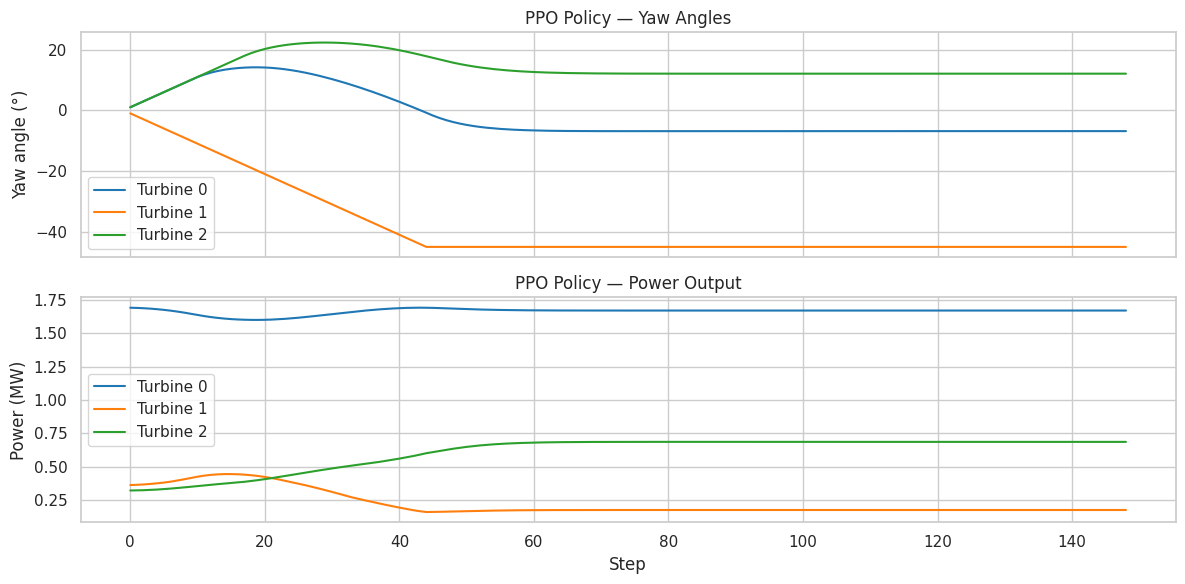

In [ ]:
colors = sns.color_palette("tab10", N_TURBINES)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"yaw_{i}"],
            color=colors[i], label=f"Turbine {i}")
ax.set_ylabel("Yaw angle (°)")
ax.set_title("PPO Policy — Yaw Angles")
ax.legend()

ax = axes[1]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"power_{i}"],
            color=colors[i], label=f"Turbine {i}")
ax.set_xlabel("Step")
ax.set_ylabel("Power (MW)")
ax.set_title("PPO Policy — Power Output")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:

for i in range(N_TURBINES):
    print(f"{i}: {eval_df['step'].iloc[0]}, {eval_df[f'yaw_{i}'].iloc[0]}")

0: 0, 1.0
1: 0, -1.0
2: 0, 1.0


## Final Comparison

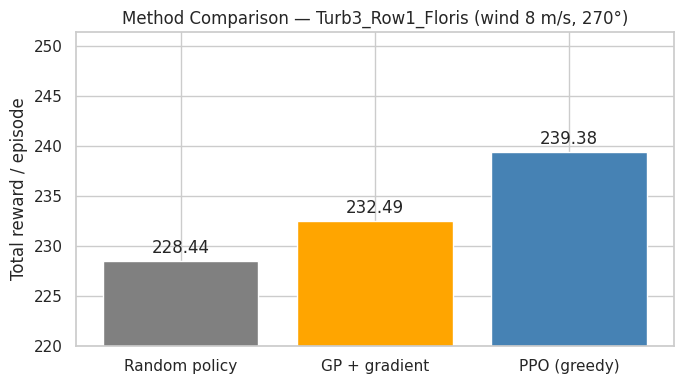


Summary:
  Random policy       : 228.44
  GP + gradient       : 232.49
  PPO (greedy)        : 239.38


In [ ]:
results = {
    "Random policy": 228.44,
    "GP + gradient": 232.49,
    "PPO (greedy)":  np.mean(eval_rewards),
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results.keys(), results.values(),
              color=["gray", "orange", "steelblue"])
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Total reward / episode")
ax.set_title("Method Comparison — Turb3_Row1_Floris (wind 8 m/s, 270°)")
ax.set_ylim(220, max(results.values()) * 1.05)
plt.tight_layout()
plt.show()

print("\nSummary:")
for name, val in results.items():
    print(f"  {name:<20s}: {val:.2f}")